In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))

In [2]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from process_data import DataProcessor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
data_path = '../data/firebox_data/FIREbox_z=0.txt'
data_processor = DataProcessor(file_path=data_path)
data = data_processor.load_data()

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160502 entries, 0 to 199491
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   haloID              160502 non-null  int64  
 1   hostHaloID          160502 non-null  int64  
 2   lg_Mhalo            160502 non-null  float64
 3   Rhalo               160502 non-null  float64
 4   pos_x               160502 non-null  float64
 5   pos_y               160502 non-null  float64
 6   pos_z               160502 non-null  float64
 7   vel_x               160502 non-null  float64
 8   vel_y               160502 non-null  float64
 9   vel_z               160502 non-null  float64
 10  lg_Mstar_<Rhalo     160502 non-null  float64
 11  lg_Mstar_<0.1Rhalo  160502 non-null  float64
 12  lg_Mstar_<10kpc     160502 non-null  float64
dtypes: float64(11), int64(2)
memory usage: 17.1 MB


In [7]:
# filtering out rows without stellar mass
data_with_lg_Mstar = data[(data['lg_Mstar_<Rhalo']>=0) & (data['lg_Mhalo']>9.5)]

# selecting features (stellar observables) and target (halo mass)
feature_cols = ['Rhalo', 'pos_x', 'pos_y', 'pos_z',\
                'vel_x', 'vel_y', 'vel_z', 'lg_Mstar_<Rhalo']
target_col = 'lg_Mhalo'

X = np.array(data_with_lg_Mstar[feature_cols])
y = np.array(data_with_lg_Mstar[target_col])


# stratifying the halo mass for the train-test split
bins = np.percentile(y, np.linspace(0, 100, 11))
y_bins = np.digitize(y, bins[1:-1])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y_bins)

In [8]:

# Initialize Random Forest Regressor with carefully chosen parameters
rf_model = RandomForestRegressor(
    n_estimators=100,        # Number of trees in the forest
    max_depth=10,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required at a leaf node
    max_features='sqrt',     # Number of features to consider for best split
    random_state=42,         # For reproducibility
    n_jobs=-1,              # Use all available cores
    bootstrap=True,          # Bootstrap sampling for each tree
    oob_score=True          # Calculate out-of-bag score
)

print("Random Forest Parameters:")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth: {rf_model.max_depth}")
print(f"Min samples to split: {rf_model.min_samples_split}")
print(f"Min samples at leaf: {rf_model.min_samples_leaf}")
print(f"Max features: {rf_model.max_features}")
print(f"Bootstrap: {rf_model.bootstrap}")
print(f"OOB score enabled: {rf_model.oob_score}")


Random Forest Parameters:
Number of trees: 100
Max depth: 10
Min samples to split: 5
Min samples at leaf: 2
Max features: sqrt
Bootstrap: True
OOB score enabled: True


In [9]:
# Train the Random Forest model
print("Training Random Forest model...")
rf_model.fit(X_train, y_train)

# Make predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

print("Model training completed!")
print(f"Out-of-bag score: {rf_model.oob_score_:.4f}")
print(f"Number of features used: {rf_model.n_features_in_}")
print(f"Feature names: {feature_cols}")


Training Random Forest model...
Model training completed!
Out-of-bag score: 0.9817
Number of features used: 8
Feature names: ['Rhalo', 'pos_x', 'pos_y', 'pos_z', 'vel_x', 'vel_y', 'vel_z', 'lg_Mstar_<Rhalo']


In [10]:
# Calculate performance metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("="*50)
print("RANDOM FOREST PERFORMANCE METRICS")
print("="*50)
print(f"Training Set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")
print()
print(f"Test Set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")
print()
print(f"Out-of-bag R²: {rf_model.oob_score_:.4f}")


RANDOM FOREST PERFORMANCE METRICS
Training Set:
  RMSE: 0.0458
  MAE:  0.0274
  R²:   0.9931

Test Set:
  RMSE: 0.0644
  MAE:  0.0399
  R²:   0.9855

Out-of-bag R²: 0.9817


PERMUTATION FEATURE IMPORTANCE RANKING
Feature              Importance   Std Dev   
------------------------------------------------------------
Rhalo                0.2085       0.0136    
lg_Mstar_<Rhalo      0.1055       0.0084    
vel_y                0.0003       0.0002    
pos_y                0.0002       0.0001    
vel_z                0.0002       0.0001    
pos_x                0.0001       0.0001    
vel_x                -0.0000      0.0001    
pos_z                -0.0000      0.0001    


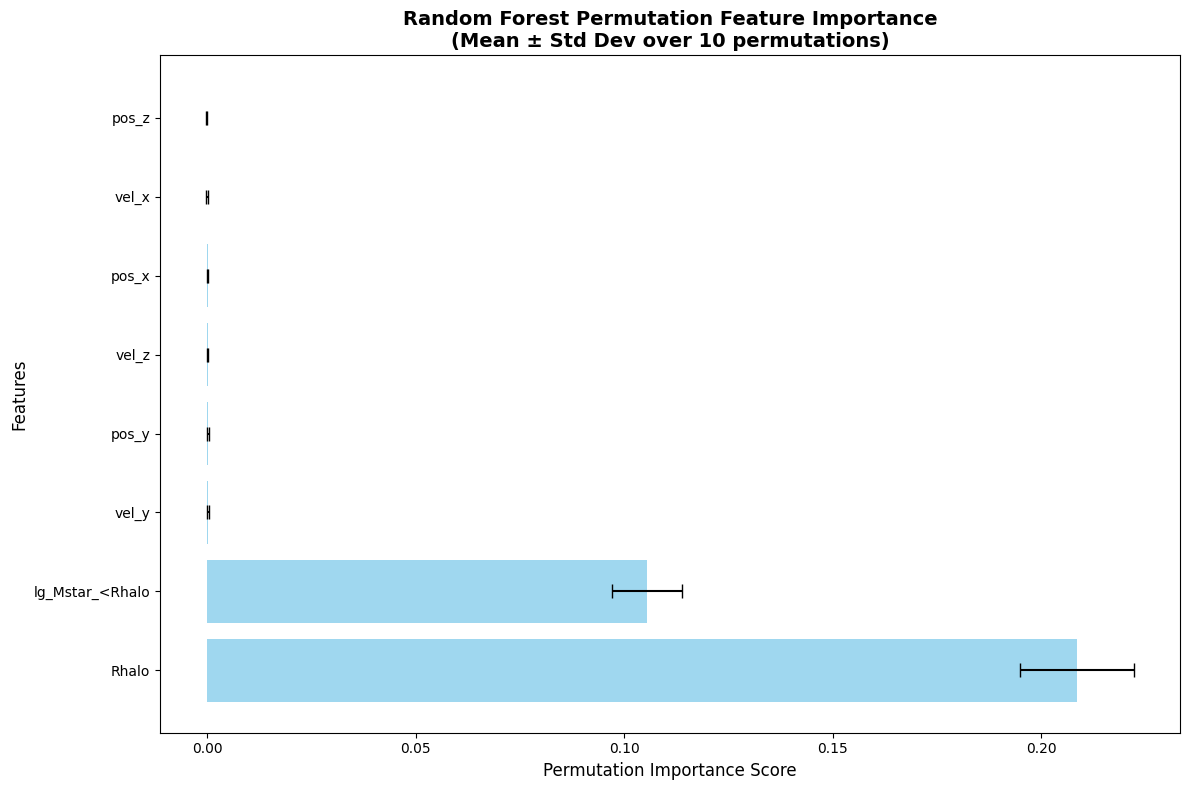


Note: Permutation importance measures the decrease in model performance
when each feature is randomly shuffled. Higher values indicate more important features.


In [11]:
# Feature Importance Analysis using Permutation Importance
from sklearn.inspection import permutation_importance

# Calculate permutation importance on test set
perm_importance = permutation_importance(
    rf_model, X_test, y_test, 
    n_repeats=10,           # Number of times to permute each feature
    random_state=42,        # For reproducibility
    scoring='neg_mean_squared_error'  # Use MSE as scoring metric
)

# Extract importance scores and standard deviations
feature_names = feature_cols
perm_scores = perm_importance.importances_mean
perm_stds = perm_importance.importances_std

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_scores,
    'std': perm_stds
}).sort_values('importance', ascending=False)

print("="*60)
print("PERMUTATION FEATURE IMPORTANCE RANKING")
print("="*60)
print(f"{'Feature':<20} {'Importance':<12} {'Std Dev':<10}")
print("-" * 60)
for idx, row in importance_df.iterrows():
    print(f"{row['feature']:<20} {row['importance']:<12.4f} {row['std']:<10.4f}")

# Visualize permutation importance with error bars
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(importance_df))
plt.barh(y_pos, importance_df['importance'], 
         xerr=importance_df['std'], 
         capsize=5, 
         color='skyblue', 
         alpha=0.8)

plt.yticks(y_pos, importance_df['feature'])
plt.xlabel('Permutation Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Random Forest Permutation Feature Importance\n(Mean ± Std Dev over 10 permutations)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nNote: Permutation importance measures the decrease in model performance")
print(f"when each feature is randomly shuffled. Higher values indicate more important features.")


COMPARISON: BUILT-IN vs PERMUTATION IMPORTANCE
Feature              Built-in     Permutation  Difference  
----------------------------------------------------------------------
Rhalo                0.5082       0.2085       -0.2997     
lg_Mstar_<Rhalo      0.4299       0.1055       -0.3244     
vel_y                0.0111       0.0003       -0.0108     
pos_y                0.0139       0.0002       -0.0137     
vel_z                0.0085       0.0002       -0.0083     
pos_x                0.0107       0.0001       -0.0105     
vel_x                0.0084       -0.0000      -0.0084     
pos_z                0.0093       -0.0000      -0.0093     


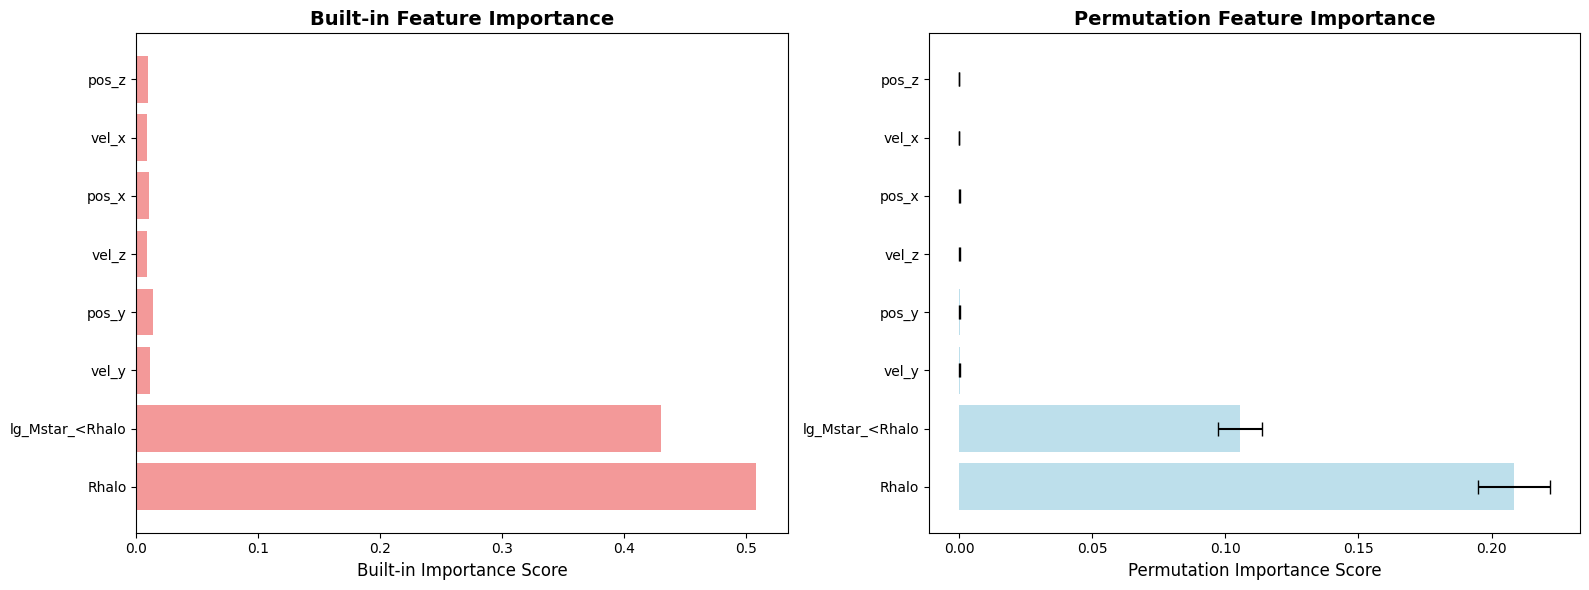


Key Differences:
• Built-in importance: Based on impurity reduction during training
• Permutation importance: Based on actual performance impact on test data
• Permutation importance is generally more reliable for feature selection


In [12]:
# Compare Built-in vs Permutation Importance
print("="*70)
print("COMPARISON: BUILT-IN vs PERMUTATION IMPORTANCE")
print("="*70)

# Get built-in feature importance for comparison
builtin_importance = rf_model.feature_importances_

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'feature': feature_names,
    'builtin_importance': builtin_importance,
    'permutation_importance': perm_scores,
    'permutation_std': perm_stds
}).sort_values('permutation_importance', ascending=False)

print(f"{'Feature':<20} {'Built-in':<12} {'Permutation':<12} {'Difference':<12}")
print("-" * 70)
for idx, row in comparison_df.iterrows():
    diff = row['permutation_importance'] - row['builtin_importance']
    print(f"{row['feature']:<20} {row['builtin_importance']:<12.4f} {row['permutation_importance']:<12.4f} {diff:<12.4f}")

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Built-in importance
y_pos = np.arange(len(comparison_df))
ax1.barh(y_pos, comparison_df['builtin_importance'], color='lightcoral', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(comparison_df['feature'])
ax1.set_xlabel('Built-in Importance Score', fontsize=12)
ax1.set_title('Built-in Feature Importance', fontsize=14, fontweight='bold')

# Permutation importance with error bars
ax2.barh(y_pos, comparison_df['permutation_importance'], 
         xerr=comparison_df['permutation_std'], 
         capsize=5, color='lightblue', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(comparison_df['feature'])
ax2.set_xlabel('Permutation Importance Score', fontsize=12)
ax2.set_title('Permutation Feature Importance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nKey Differences:")
print(f"• Built-in importance: Based on impurity reduction during training")
print(f"• Permutation importance: Based on actual performance impact on test data")
print(f"• Permutation importance is generally more reliable for feature selection")


<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\3165728173.py:7: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel('True $\log M_{halo}$', fontsize=12)
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\3165728173.py:8: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('Predicted $\log M_{halo}$', fontsize=12)
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\3165728173.py:14: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel('True $\log M_{halo}$', fontsize=12)


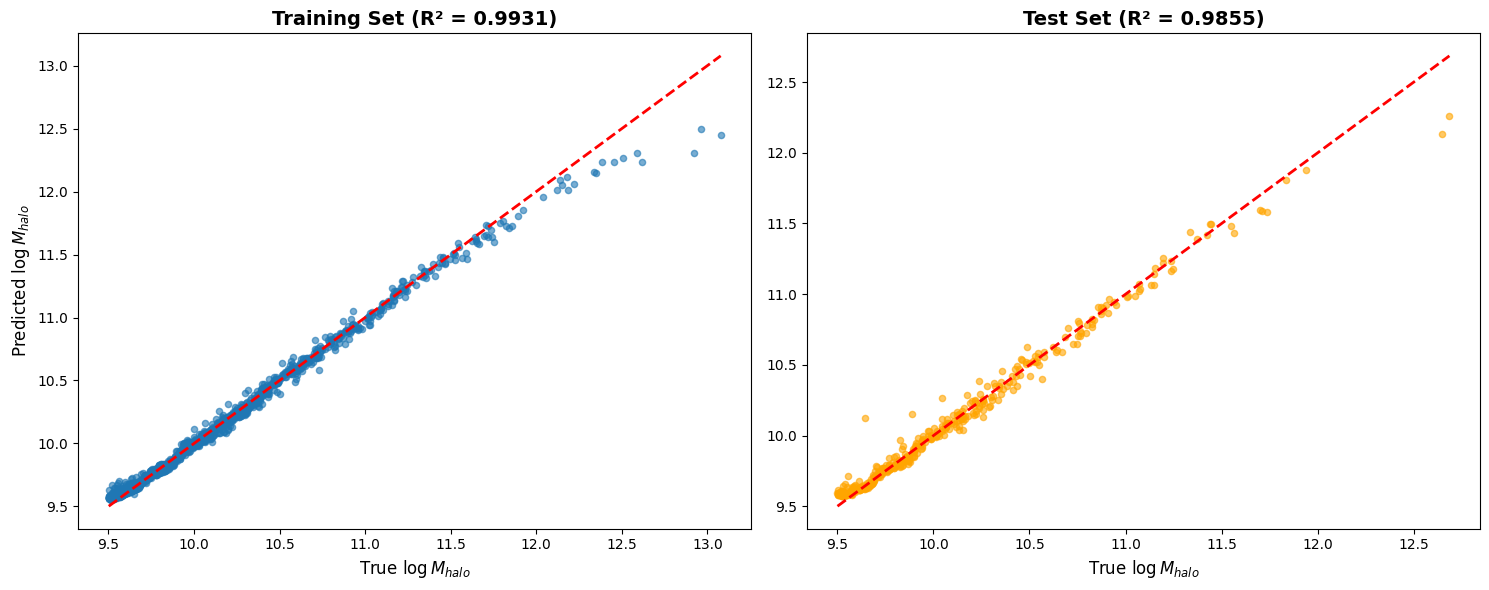

In [19]:
# Prediction vs Actual Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Training set predictions
axes[0].scatter(y_train, y_train_pred, alpha=0.6, s=20)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[0].set_ylabel('Predicted $\log M_{halo}$', fontsize=12)
axes[0].set_title(f'Training Set (R² = {train_r2:.4f})', fontsize=14, fontweight='bold')

# Test set predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=20, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:10: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\3328044224.py:10: SyntaxWarning: invalid escape sequence '\l'
  axes[0, 0].set_xlabel('True $\log M_{halo}$', fontsize=12)
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\3328044224.py:17: SyntaxWarning: invalid escape sequence '\l'
  axes[0, 1].set_xlabel('True $\log M_{halo}$', fontsize=12)


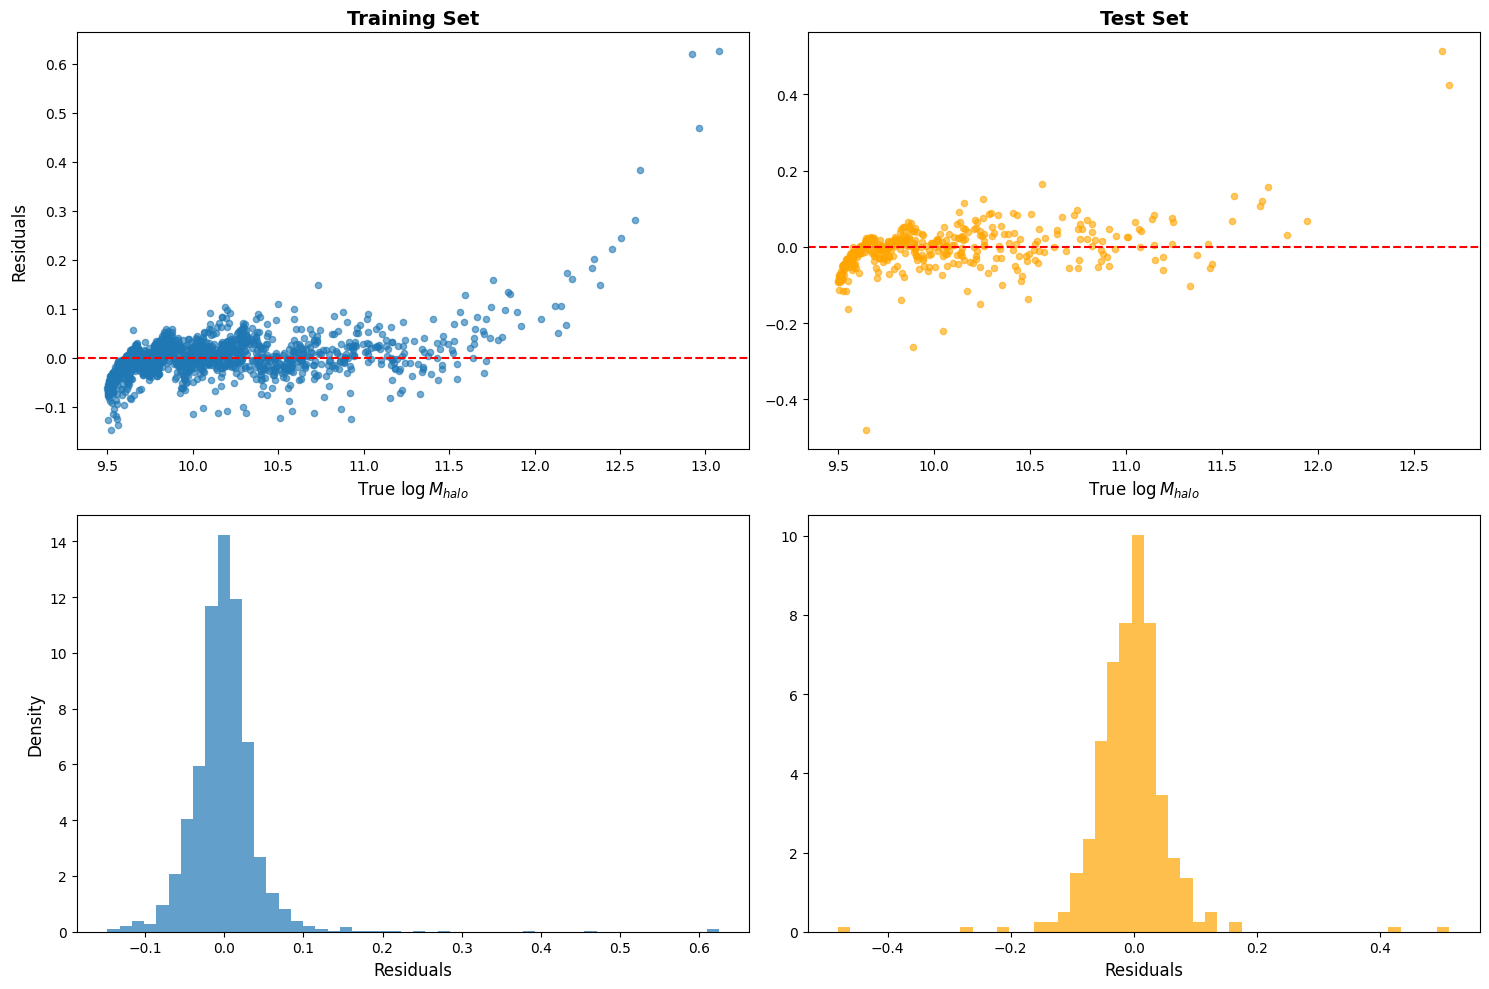

Training residuals - Mean: -0.0002, Std: 0.0458
Test residuals - Mean: -0.0047, Std: 0.0642


In [15]:
# Residual Analysis
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training residuals vs predicted
axes[0, 0].scatter(y_train, train_residuals, alpha=0.6, s=20)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[0, 0].set_ylabel('Residuals', fontsize=12)
axes[0, 0].set_title('Training Set', fontsize=14, fontweight='bold')

# Test residuals vs predicted
axes[0, 1].scatter(y_test, test_residuals, alpha=0.6, s=20, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[0, 1].set_title('Test Set', fontsize=14, fontweight='bold')

# Training residuals histogram
axes[1, 0].hist(train_residuals, bins=50, alpha=0.7, density=True)
axes[1, 0].set_xlabel('Residuals', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)

# Test residuals histogram
axes[1, 1].hist(test_residuals, bins=50, alpha=0.7, color='orange', density=True)
axes[1, 1].set_xlabel('Residuals', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Training residuals - Mean: {train_residuals.mean():.4f}, Std: {train_residuals.std():.4f}")
print(f"Test residuals - Mean: {test_residuals.mean():.4f}, Std: {test_residuals.std():.4f}")


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:7: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\1013249087.py:6: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_xlabel('True $\log M_{halo}$', fontsize=12)
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\1013249087.py:7: SyntaxWarning: invalid escape sequence '\l'
  axes[0].set_ylabel('Pred $\log M_{halo} -$ True $\log M_{halo}$')
C:\Users\Abdelrahman Helal\AppData\Local\Temp\ipykernel_16716\1013249087.py:12: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_xlabel('True $\log M_{halo}$', fontsize=12)
C:\Users\Abdelrahman Helal\AppData\Local\T

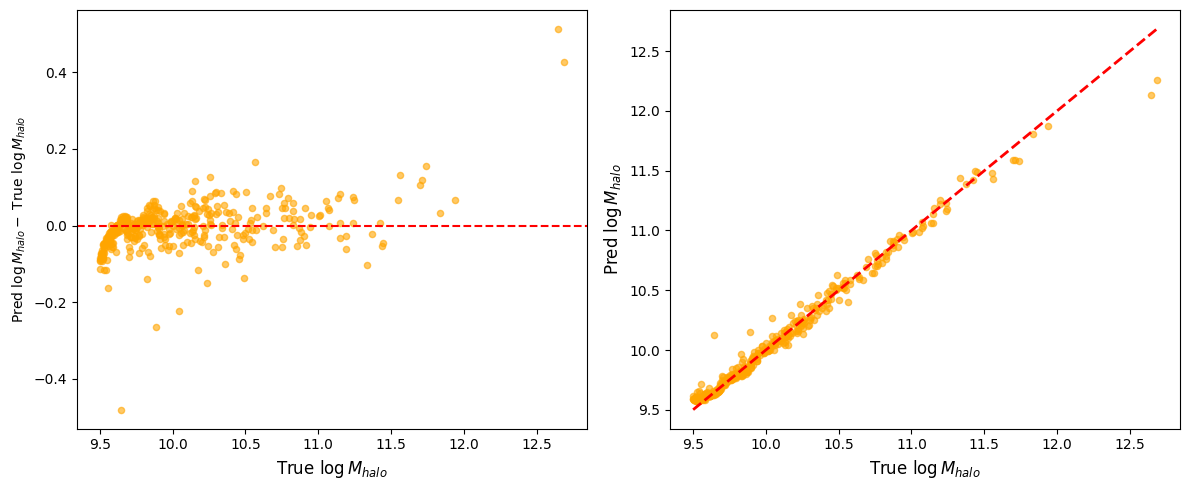

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set predictions
axes[0].scatter(y_test, test_residuals, alpha=0.6, s=20, color='orange')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[0].set_ylabel('True $\log M_{halo} -$ Pred $\log M_{halo}$')

# Test set predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.6, s=20, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('True $\log M_{halo}$', fontsize=12)
axes[1].set_ylabel('Pred $\log M_{halo}$', fontsize=12)
#axes[1].set_title(f'Test Set (R² = {test_r2:.4f})', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()